<a href="https://colab.research.google.com/github/zehraz1/Machine-Learning-Project/blob/main/ENSF444Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENSF 444 PROJECT

Project Title: Predicting Job Offer Salaries for College Students

Names: Zehra Zaidi, Ifiorah Makochukwu, Osadebamwen Ekhator



In this project, we aim to predict job offer salaries for college students

Initial imports.

In [ ]:
# imports
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate


Load the dataset and search for any missing values. You can download the dataset from here: https://www.kaggle.com/datasets/likithagedipudi/job-board-effectiveness-for-college-students

In [ ]:
# load dataset
uploaded = files.upload()
df = pd.read_csv('job_search_platform_efficacy_100k.csv')
print(df.head())

print("Missing values right after loading:")
print(df.isnull().sum())

Saving job_search_platform_efficacy_100k.csv to job_search_platform_efficacy_100k.csv
   Student_ID University_Rating School_Size     Region Major_Category   GPA  \
0  STU_000001          Mid-tier      Medium       West     Healthcare  2.81   
1  STU_000002        Lower-tier      Medium  Northeast           STEM  2.61   
2  STU_000003        Lower-tier      Medium    Midwest           STEM  3.53   
3  STU_000004          Mid-tier      Medium    Midwest       Business  2.73   
4  STU_000005          Mid-tier      Medium      South       Business  4.00   

   Prior_Internships  Extra_Curricular_Activities  Networking_Events_Attended  \
0                  3                            2                           6   
1                  1                            1                           6   
2                  3                            2                           2   
3                  0                            2                           1   
4                  1              

Filter and preprocess dataset. We only want rows that have an "Offer_Received" and we want to drop any irrelevant rows.

In [ ]:
# Filter for rows where Offer_Received is 1
df_cleaned = df[df['Offer_Received'] == 1].copy()

# Remove rows where the target (Offer_Salary) is missing
df_cleaned = df_cleaned.dropna(subset=['Offer_Salary'])

# Drop Student_ID and post-offer columns to avoid data leakage and memory issues
cols_to_drop = ['Student_ID', 'Offer_Received', 'Accepted_Offer']
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

print(f"Dataset cleaned. Remaining records for training: {len(df_cleaned)}")

# View basic statistics about the cleaned data
print(df_cleaned.describe())

print("Missing values right after loading:")
print(df_cleaned.isnull().sum())

Dataset cleaned. Remaining records for training: 34229
                GPA  Prior_Internships  Extra_Curricular_Activities  \
count  34229.000000       34229.000000                 34229.000000   
mean       3.244201           1.543078                     2.014958   
std        0.400699           1.201039                     1.414610   
min        2.000000           0.000000                     0.000000   
25%        2.970000           1.000000                     1.000000   
50%        3.250000           1.000000                     2.000000   
75%        3.530000           2.000000                     3.000000   
max        4.000000           5.000000                    10.000000   

       Networking_Events_Attended  Months_Searching  Applications_Submitted  \
count                34229.000000      34229.000000            34229.000000   
mean                     3.000935          6.737620               54.451518   
std                      1.737104          3.419668               43

Plot the data.


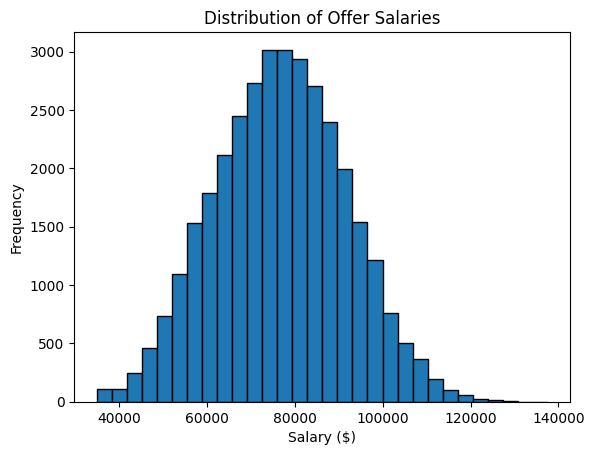

In [ ]:
# Visualize the data - Histogram of salaries
import matplotlib.pyplot as plt
plt.hist(df['Offer_Salary'], bins=30, edgecolor='black')
plt.title('Distribution of Offer Salaries')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.show()

Separate features and target.

In [ ]:
# Separate features and target
X = df_cleaned.drop('Offer_Salary', axis=1)
y = df_cleaned['Offer_Salary']

Use One Hot Encoding.

In [ ]:
# Use One Hot Encoding to convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)
train_columns = X.columns

print(X.columns.tolist()) # Added just to see which new columns were created afer encoding

print(f"Features shape after encoding: {X.shape}")


['GPA', 'Prior_Internships', 'Extra_Curricular_Activities', 'Networking_Events_Attended', 'Months_Searching', 'Applications_Submitted', 'First_Round_Interviews', 'Second_Round_Interviews', 'Time_to_Offer_Days', 'Role_Relevance', 'University_Rating_Mid-tier', 'University_Rating_Top-tier', 'School_Size_Medium', 'School_Size_Small', 'Region_Northeast', 'Region_South', 'Region_West', 'Major_Category_Business', 'Major_Category_Healthcare', 'Major_Category_Humanities', 'Major_Category_STEM', 'Primary_Search_Platform_Indeed', 'Primary_Search_Platform_LinkedIn', 'Company_Size_Offered_Mid-Size', 'Company_Size_Offered_Startup']
Features shape after encoding: (34229, 25)


Split 20% of the data for the testing set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 27383 samples
Testing set: 6846 samples


# Linear Regression


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize model with a pipeline
# scale numerical features before fitting the regression so all features are ranked fairly
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Cross-validation on training data
scores = cross_validate(lr_model, X_train, y_train, scoring='r2', cv=5, return_train_score=True)

print("training r2 = {:.3f}".format(scores['train_score'].mean()))
print("validation r2 = {:.3f}".format(scores['test_score'].mean()))

# Fit model on full training set
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)

# Evaluate on test set
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Testing R² score:", round(r2, 3))
print("Test MAE: {:,.2f}".format(mae))

training r2 = 0.714
validation r2 = 0.713
Testing R² score: 0.71
Test MAE: 6,323.52


# Random Forest

In [ ]:
#select and validate the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

rf_model = RandomForestRegressor(random_state=0, max_depth=10, min_samples_leaf=15, max_features=0.5)

scores = cross_validate(rf_model, X_train, y_train, scoring='r2', cv=5, return_train_score=True)

print("training r2 = {:.3f}".format(scores['train_score'].mean()))
print("validation r2 = {:.3f}".format(scores['test_score'].mean()))

training r2 = 0.741
validation r2 = 0.705


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10, 15],
    'max_features': [0.25, 0.5, 1]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=0),
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='r2', n_jobs=-1
)

random_search.fit(X_train, y_train)
rf_model = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("Testing R² score:", round(r2, 3))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 15, 'max_features': 0.5, 'max_depth': 10}
Testing R² score: 0.705
Test MAE: 6401.782833897648


# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=0),
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='r2', n_jobs=-1
)

random_search.fit(X_train, y_train)
gb_model = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate

# Use the best model from Cell 1
y_pred = gb_model.predict(X_test)

scores = cross_validate(gb_model, X_train, y_train, scoring='r2', cv=5, return_train_score=True)
print(f"training r2 = {scores['train_score'].mean():.3f}")
print(f"validation r2 = {scores['test_score'].mean():.3f}")
print(f"Testing R² score: {r2_score(y_test, y_pred):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# Comparisons

In [ ]:
import seaborn as sns

# Store results in a dictionary
results = {
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2 Score': [],
    'MAE': []
}

# Collect Linear Regression results
y_pred_lr = lr_model.predict(X_test)
results['R2 Score'].append(r2_score(y_test, y_pred_lr))
results['MAE'].append(mean_absolute_error(y_test, y_pred_lr))

# Collect Random Forest results
y_pred_rf = rf_model.predict(X_test)
results['R2 Score'].append(r2_score(y_test, y_pred_rf))
results['MAE'].append(mean_absolute_error(y_test, y_pred_rf))

# Collect Gradient Boosting results
y_pred_gb = gb_model.predict(X_test)
results['R2 Score'].append(r2_score(y_test, y_pred_gb))
results['MAE'].append(mean_absolute_error(y_test, y_pred_gb))

# Display the comparison table
comparison_df = pd.DataFrame(results)
print(comparison_df.sort_values(by='R2 Score', ascending=False))

# Plot the comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2 Score', data=comparison_df, palette='viridis')
plt.title('R² Score Comparison')
plt.ylim(0, 1) # because R2 usually stays between 0 and 1
plt.savefig('model_comparison.png')

In [ ]:
# finding the most important features
importances = gb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head()

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Factors Influencing Salary Predictions')
plt.show()

In [ ]:

def predict_salary(input_data, model, train_columns):
    input_df = pd.DataFrame([input_data])
    input_df = pd.get_dummies(input_df, drop_first=True)
    input_df = input_df.reindex(columns=train_columns, fill_value=0)

    prediction = model.predict(input_df)[0]

    print("Salary Prediction Summary")
    print("Input Information:")

    for key, value in input_data.items():
        print(f"- {key}: {value}")

    print("\n Predicted Salary: ${:,.2f}".format(prediction))

    return prediction

    # Used ChatGPT to adjust predict_salary to accommodate get_dummies encoding method

In [ ]:
sample_input = {
    'University_Rating': 'High',
    'School_Size': 'Large',
    'Region': 'Northeast',
    'Major_Category': 'STEM',
    'GPA': 4.0,
    'Prior_Internships': 6,
    'Extra_Curricular_Activities': 3,
    'Networking_Events_Attended': 5,
    'Primary_Search_Platform': 'LinkedIn',
    'Months_Searching': 4,
    'Applications_Submitted': 25,
    'First_Round_Interviews': 6,
    'Second_Round_Interviews': 3,
    'Time_to_Offer_Days': 30,
    'Company_Size_Offered': 'Large',
    'Role_Relevance': 9
}

best_model = lr_model
predicted_salary = predict_salary(sample_input, best_model, train_columns)

# used ChatGPT to generate sample input

In [ ]:
user_input = {
    'University_Rating': input("University Rating: "),
    'School_Size': input("School Size: "),
    'Region': input("Region: "),
    'Major_Category': input("Major: "),
    'GPA': float(input("GPA: ")),
    'Prior_Internships': int(input("Internships: ")),
    'Extra_Curricular_Activities': int(input("Activities: ")),
    'Networking_Events_Attended': int(input("Networking Events: ")),
    'Primary_Search_Platform': input("Platform: "),
    'Months_Searching': int(input("Months Searching: ")),
    'Applications_Submitted': int(input("Applications: ")),
    'First_Round_Interviews': int(input("First Interviews: ")),
    'Second_Round_Interviews': int(input("Second Interviews: ")),
    'Time_to_Offer_Days': int(input("Days to Offer: ")),
    'Company_Size_Offered': input("Company Size: "),
    'Role_Relevance': int(input("Role Relevance: "))
}

best_model = lr_model
predicted_salary = predict_salary(user_input, best_model, train_columns)

# used ChatGPT to generate format for user input